# Autoregressive (Rolling) Error Analysis
This notebook analyzes the error accumulation over time for Initial-Value Problem (IVP) rolling predictions.
It computes the Valid Prediction Horizon (VPH) and generates spatial error heatmaps to pinpoint the source of divergence.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
import os

# Set a nice plotting style
plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 6)})


## 1. Load Data
Specify the path to the `rolling_sequence` output directory of your model run.

In [13]:
# Update this path to your specific rolling_sequence run
# RESULTS_DIR = Path('/scratch/yl75/ak4177/results/groundwater/GINO_predictions/var_loss/resolution_0.3/gino_predictions_20260817_150554/rolling_sequence')
GINO_RESULTS_DIR = Path('/scratch/yl75/ak4177/results/groundwater/GINO_predictions/var_loss/resolution_1.0/gino_predictions_20260817_161903/rolling_sequence')
FNO_RESULTS_DIR = Path('/scratch/yl75/ak4177/results/groundwater/FNO_predictions/forcing/resolution_1.0/fno_predictions_20260818_085739/rolling_sequence')

# Load metadata
with open(RESULTS_DIR / 'metadata.json', 'r') as f:
    metadata = json.load(f)
    
target_cols = metadata.get('args', {}).get('target_cols', ['mass_concentration', 'head'])
print(f"Target columns: {target_cols}")

# Load predictions and targets
# Shape is typically [N_timesteps, N_points, W_out, N_cols]
print("Loading arrays (this may take a moment)...")
preds = np.load(RESULTS_DIR / 'val_predictions.npy')
targets = np.load(RESULTS_DIR / 'val_targets.npy')

print(f"Predictions shape: {preds.shape}")
print(f"Targets shape: {targets.shape}")

n_steps, n_points, w_out, n_cols = preds.shape


Target columns: ['mass_concentration', 'head']
Loading arrays (this may take a moment)...
Predictions shape: (568, 61360, 1, 2)
Targets shape: (568, 61360, 1, 2)


## 2. Compute Spatially Averaged Error over Time
We calculate the Relative L2 Error and Root Mean Squared Error (RMSE) at each timestep.

In [14]:
def calculate_errors_vs_time(preds, targets, n_steps, n_cols):
    rel_l2 = np.zeros((n_cols, n_steps))
    rmse = np.zeros((n_cols, n_steps))
    
    for c in range(n_cols):
        for t in range(n_steps):
            p_t = preds[t, :, 0, c]
            t_t = targets[t, :, 0, c]
            
            diff = p_t - t_t
            rmse[c, t] = np.sqrt(np.mean(diff**2))
            
            target_norm = np.linalg.norm(t_t)
            if target_norm > 1e-8:
                rel_l2[c, t] = np.linalg.norm(diff) / target_norm
            else:
                rel_l2[c, t] = np.linalg.norm(diff) # fallback if target is all 0
                
    return rel_l2, rmse

rel_l2, rmse = calculate_errors_vs_time(preds, targets, n_steps, n_cols)


## 3. Valid Prediction Horizon (VPH)
VPH is defined as the number of consecutive timesteps the model stays below a specific relative error threshold (e.g., 10% or 20%).

In [15]:
def compute_vph(rel_l2, threshold=0.20):
    vph = {}
    for c, col in enumerate(target_cols):
        errors = rel_l2[c]
        # Find first timestep where error exceeds threshold
        exceed_idx = np.where(errors > threshold)[0]
        if len(exceed_idx) > 0:
            vph[col] = exceed_idx[0]
        else:
            vph[col] = len(errors)  # Never exceeded
    return vph

vph_10 = compute_vph(rel_l2, threshold=0.10)
vph_20 = compute_vph(rel_l2, threshold=0.20)
vph_40 = compute_vph(rel_l2, threshold=0.40)

print("--- Valid Prediction Horizon (VPH) ---")
for col in target_cols:
    print(f"{col}:")
    print(f"  VPH @ 10% error = {vph_10[col]} steps")
    print(f"  VPH @ 20% error = {vph_20[col]} steps")
    print(f"  VPH @ 40% error = {vph_40[col]} steps")


--- Valid Prediction Horizon (VPH) ---
mass_concentration:
  VPH @ 10% error = 0 steps
  VPH @ 20% error = 5 steps
  VPH @ 40% error = 568 steps
head:
  VPH @ 10% error = 0 steps
  VPH @ 20% error = 3 steps
  VPH @ 40% error = 99 steps


## 4. Plot Error Accumulation

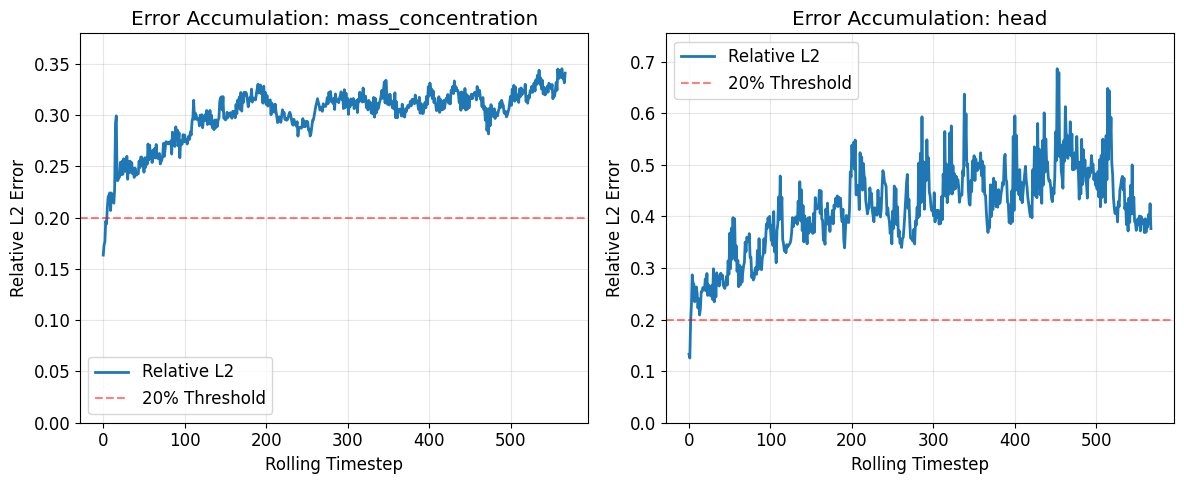

In [16]:
fig, axes = plt.subplots(1, n_cols, figsize=(6*n_cols, 5))
if n_cols == 1: axes = [axes]

for c, (col, ax) in enumerate(zip(target_cols, axes)):
    ax.plot(rel_l2[c,:], lw=2, label='Relative L2')
    ax.axhline(0.20, color='r', linestyle='--', alpha=0.5, label='20% Threshold')
    
    # Limit y-axis if error explodes to infinity to keep it readable
    max_y = min(2.0, np.nanmax(rel_l2[c])) if np.nanmax(rel_l2[c]) > 0 else 1.0
    ax.set_ylim(0, max_y * 1.1)
    
    ax.set_xlabel('Rolling Timestep')
    ax.set_ylabel('Relative L2 Error')
    ax.set_title(f'Error Accumulation: {col}')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
